In [1]:
from EncoderDecoder.utils import loadData
import matplotlib.pyplot as plt
import logging
import pandas as pd
import matplotlib.pyplot as plt
import re
logging.disable(logging.CRITICAL)

In [2]:
import os

#add the root directory
os.chdir('../')

## Visualize f-PV_heu manifolds colored by major species as exploratory phase

Observations:
- Major species selected by Malik are well distributed over the manifold


In [3]:
#Function to convert to Latex format for nice printing

def latex_species(species):
    """
    Convert a species name to a LaTeX-formatted string.

    Examples
    --------
    CH4   -> CH$_4$
    H2O   -> H$_2$O
    CO2   -> CO$_2$
    H2O2  -> H$_2$O$_2$
    C2H6  -> C$_2$H$_6$
    NO    -> NO
    """
    return re.sub(r'(\d+)', r'$_\1$', species)

### Load dataset

In [4]:
path = "data-files/"
name_mf = "Malik-mf-CFLF-2022.csv"
name_T = "Malik-T-CFLF-2022.csv"
name_state_space = "Malik-state-space-CFLF-2022.csv"
name_state_space_source = "Malik-state-space_source-CFLF-2022.csv"

data_mf = pd.read_csv(path + name_mf)
data_T = pd.read_csv(path + name_T)
data_state_space = pd.read_csv(path + name_state_space)
data_state_space_source = pd.read_csv(path + name_state_space_source)

### Visualize major species

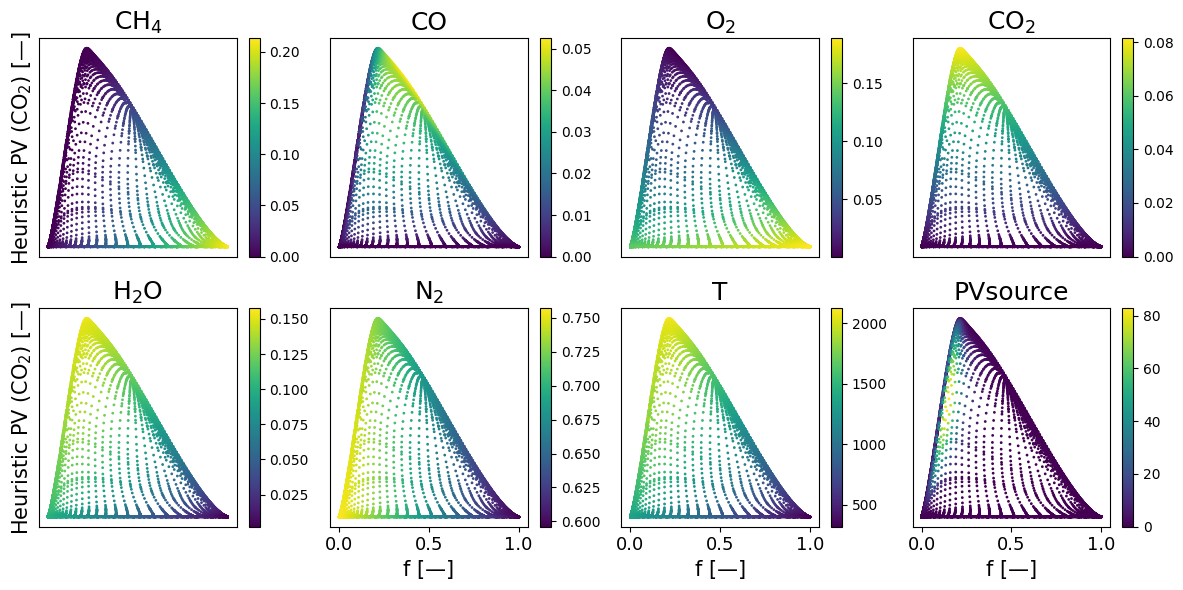

In [7]:
rows, cols = 2, 4

species = ["CH4", "CO", "O2", "CO2", "H2O", "N2"]
keys = species + ["T", "PVsource"] #"T"

# Mixture fraction
mixture_fraction = data_mf.squeeze()

# Heuristic progress variable
species_PV_heu = "CO2"
PV = data_state_space[species_PV_heu]

save = True
pathSave = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-practical-ROM/2022-Malik/Visualizations/f-PV manifolds/Heuristic/"
name = f"f-PV_heu ({species_PV_heu}) - colored by major species"

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
axes = axes.flatten()

for i, key in enumerate(keys):

    ax = axes[i]

    # Color variable
    if key in species:
        dataColor = data_state_space[key]

    elif key == "T":
        dataColor = data_T.squeeze()

    elif key == "PVsource":
        dataColor = data_state_space_source[species_PV_heu]

    # Scatter plot
    sc = ax.scatter(
        mixture_fraction,
        PV,
        c=dataColor,
        cmap="viridis",
        s=1
    )

    # x-axis formatting
    if i > len(keys) - cols:
        ax.set_xlabel("f [\u2014]", fontsize=15)
        ax.tick_params(axis="x", labelsize=13)
    else:
        ax.set_xticks([])

    # y-axis formatting
    if i % cols == 0:
        ax.set_ylabel(f"Heuristic PV ({latex_species(species_PV_heu)}) [\u2014]", fontsize=15)

    ax.set_yticks([])

    # Nice title formatting
    title = (
        latex_species(key)
    )

    ax.set_title(title, fontsize=18)

    # Individual colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(labelsize=10)

# Disable unused axes
for j in range(len(keys), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

if save:
    plt.savefig(pathSave + name, dpi=300, bbox_inches="tight")

plt.show()

### Visualize minor species

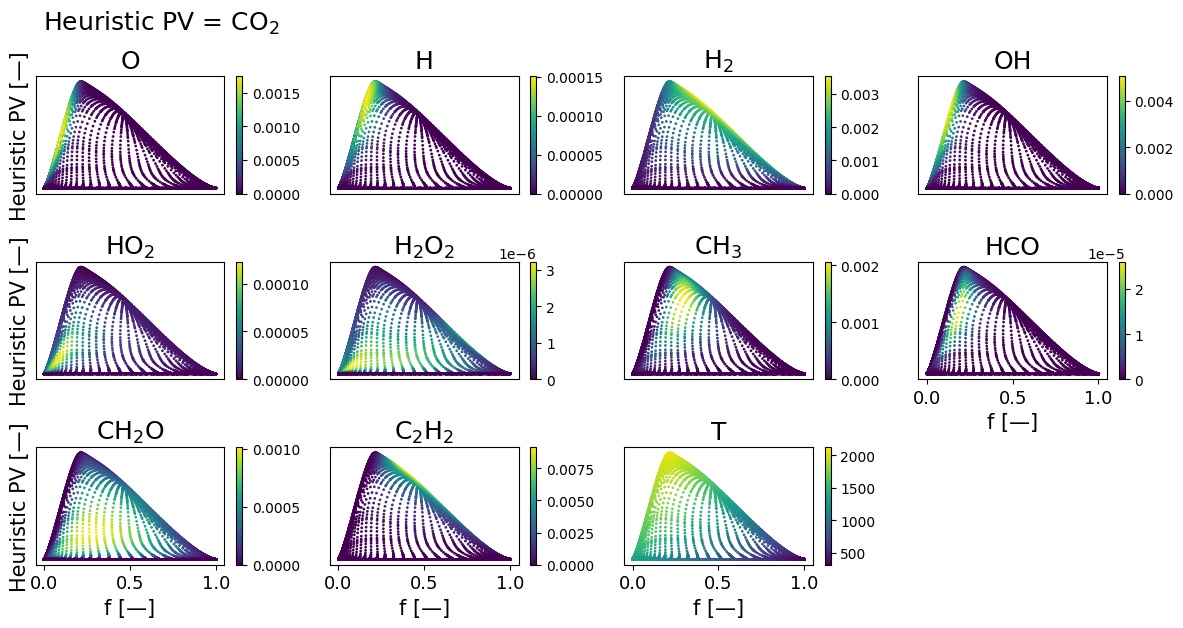

In [8]:
rows, cols = 3, 4

species = ["O", "H", "H2", "OH", "HO2", "H2O2", "CH3", "HCO", "CH2O", "C2H2"]
keys = species + ["T"] #"T", "PVsource"

# Mixture fraction
mixture_fraction = data_mf.squeeze()

# Heuristic progress variable
species_PV_heu = "CO2"
PV = data_state_space[species_PV_heu]

save = True
pathSave = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-practical-ROM/2022-Malik/Visualizations/f-PV manifolds/Heuristic/"
name = f"f-PV_heu ({species_PV_heu}) - colored by minor species"

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
axes = axes.flatten()

for i, key in enumerate(keys):

    ax = axes[i]

    # Color variable
    if key in species:
        dataColor = data_state_space[key]

    elif key == "T":
        dataColor = data_T.squeeze()

    elif key == "PVsource":
        dataColor = data_state_space_source[species_PV_heu]

    # Scatter plot
    sc = ax.scatter(
        mixture_fraction,
        PV,
        c=dataColor,
        cmap="viridis",
        s=1
    )

    # x-axis formatting
    if i >= len(keys) - cols:
        ax.set_xlabel("f [\u2014]", fontsize=15)
        ax.tick_params(axis="x", labelsize=13)
    else:
        ax.set_xticks([])

    # y-axis formatting
    if i % cols == 0:
        ax.set_ylabel(f"Heuristic PV [\u2014]", fontsize=15)

    ax.set_yticks([])

    # Nice title formatting
    title = (
        latex_species(key)
    )

    ax.set_title(title, fontsize=18)

    # Individual colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(labelsize=10)

# Disable unused axes
for j in range(len(keys), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

fig.text(
    0.04, 1.04,
    f"Heuristic PV = {latex_species(species_PV_heu)}",
    ha="left",
    va="top",
    fontsize=18
)

if save:
    plt.savefig(pathSave + name, dpi=300, bbox_inches="tight")

plt.show()

In [9]:
idx = data_state_space["CO2"].idxmax()
print(idx)
print(data_mf["f"][idx])

240
0.2155840521744958


With method 3 to compute mixture fraction, value was close to what I was expecting, but now with method 4 max CO2 is not per se close to stoich mixture fraction, but the difference is that it's not pure methane at the fuel side but diluted with air